In [58]:
import sklearn

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
 accuracy_score,
 classification_report,
 confusion_matrix
)

In [60]:
#import file
titanic_data = pd.read_csv('data/titanic.csv')

titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,PaCh,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [4]:
# You can also get this data from seaborn
import seaborn as sns
df = sns.load_dataset("titanic")

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Name      887 non-null    object 
 3   Sex       887 non-null    object 
 4   Age       887 non-null    float64
 5   SibSp     887 non-null    int64  
 6   PaCh      887 non-null    int64  
 7   Fare      887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [7]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,PaCh,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [8]:
titanic_data["Survived"].value_counts()

Survived
0    545
1    342
Name: count, dtype: int64

In [9]:
titanic_data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
PaCh        0
Fare        0
dtype: int64

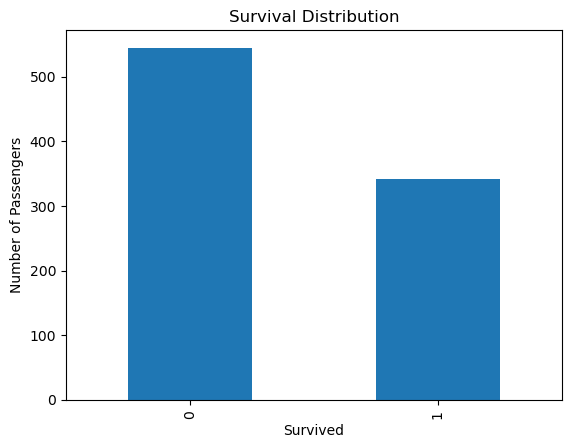

In [10]:
titanic_data["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

In [11]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'PaCh', 'Fare']
target = 'Survived'

In [20]:
X = titanic_data[features].copy()
y = titanic_data[target].copy()
titanic_data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'PaCh', 'Fare'], dtype='object')

In [21]:
X.head()

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [22]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# Convert Categorical Data

In [23]:
X['Sex'] = X['Sex'].apply(lambda x: 1 if x == 'female' else 0)

In [24]:
X.head()

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


# Split the Dataset
## Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42,stratify = y)

In [26]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (709, 6)
Testing data: (178, 6)


# Feature Scaling

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training using Logistic Regresion

In [28]:
# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_accuracy = accuracy_score(
 y_test,
 logistic_predictions
)
print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.7696629213483146


In [30]:
print(classification_report(y_test, logistic_predictions))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       109
           1       0.71      0.68      0.70        69

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.76       178
weighted avg       0.77      0.77      0.77       178



# Training Using Decision Tree

In [31]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


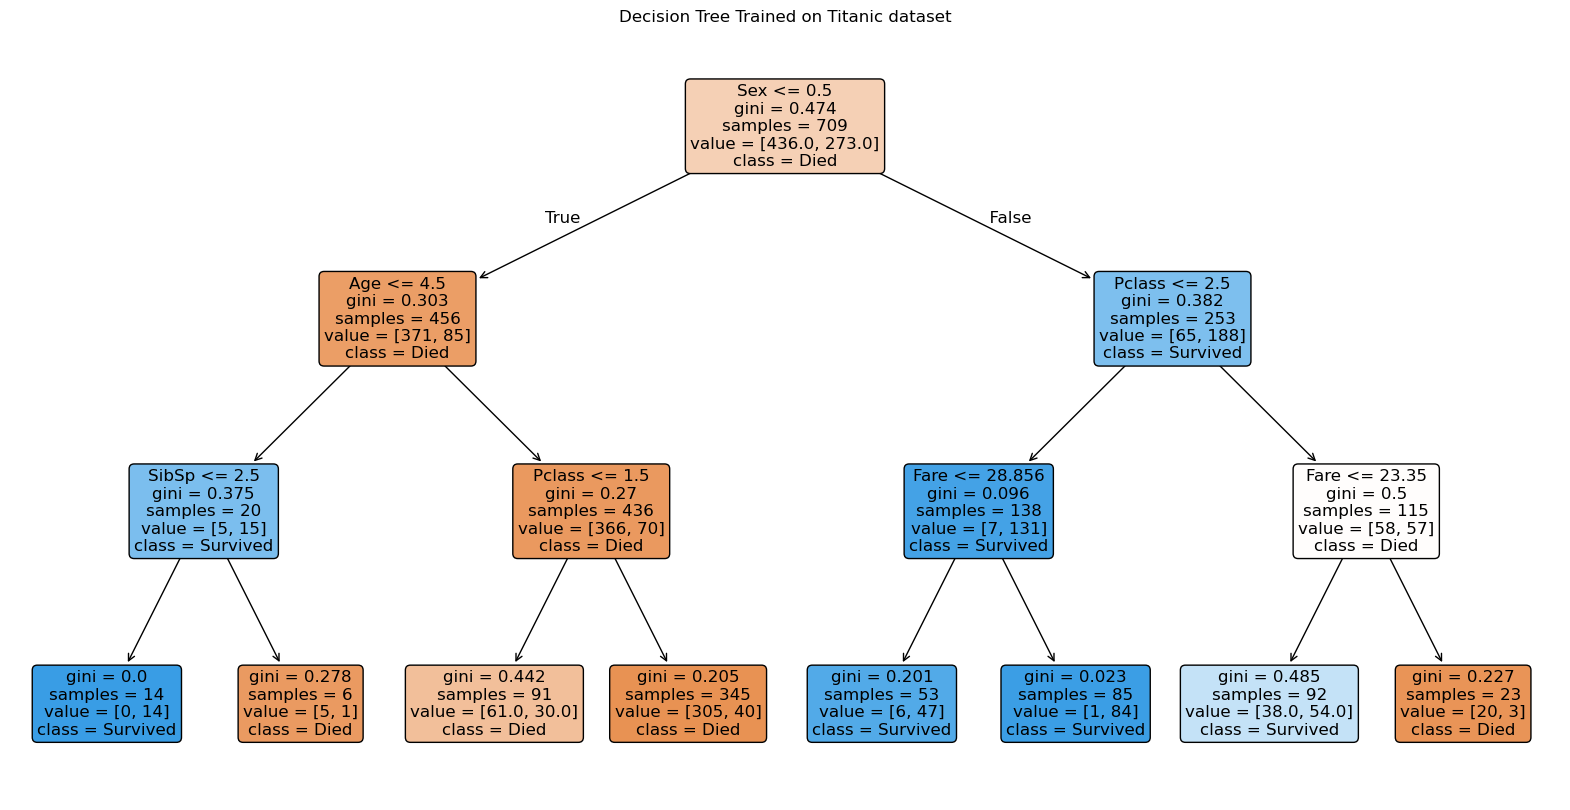

In [32]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=12,
)
plt.title("Decision Tree Trained on Titanic dataset")
plt.show()

In [33]:
tree_predictions = tree_model.predict(X_test)

tree_accuracy = accuracy_score(
 y_test,
 tree_predictions
)
print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.8033707865168539


# Training using Random Forest

In [34]:
forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3
)
        
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
forest_predictions = forest_model.predict(X_test)

forest_accuracy = accuracy_score(
 y_test,
 forest_predictions
)

print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 0.8089887640449438


In [36]:
print(classification_report(y_test, forest_predictions))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       109
           1       0.80      0.68      0.73        69

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



In [37]:
# Let's compare our Models

results = pd.DataFrame({
 "Model": [
     "Logistic Regression",
     "Decision Tree",
     "Random Forest"
 ],
 "Accuracy": [
     logistic_accuracy * 100,
     tree_accuracy * 100,
     forest_accuracy * 100
 ]
})
results.round(2)

,Model,Accuracy
0,Logistic Regression,76.97
1,Decision Tree,80.34
2,Random Forest,80.90


In [38]:
results.sort_values(
    by="Accuracy",
    ascending=False,
)

,Model,Accuracy
2,Random Forest,80.898876
1,Decision Tree,80.337079
0,Logistic Regression,76.966292


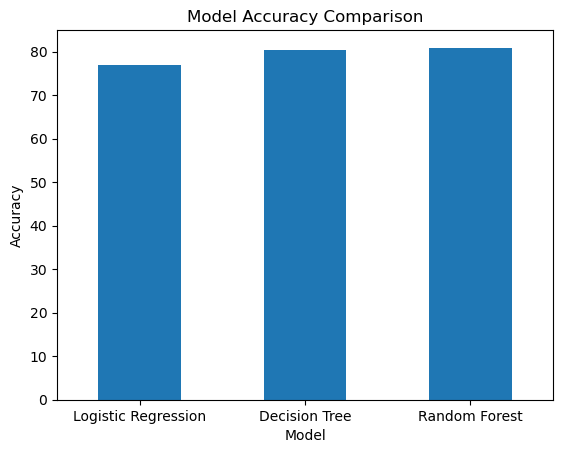

In [39]:
results.plot(
     x="Model",
     y="Accuracy",
     kind="bar",
     legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.xticks(rotation=0)

plt.show()

# Testing the model

In [40]:
input_data = [[1, 0, 30.0, 3, 0, 100]]
forest_model.predict(input_data)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

# Tuning & Optimization (hyperparameters)

In [41]:
# Tune the Decision Tree 

tree_params = { 
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
}
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params,
    cv=5,
    scoring="accuracy"
)
tree_grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [43]:
# Tune the Random Forest

forest_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10]
}
forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    forest_params,
    cv=5,
    scoring="accuracy"
)

forest_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [44]:
print("Best Parameters:")
print(forest_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(forest_grid.best_score_)

Best Parameters:
{'max_depth': 7, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.8392168614524025


In [45]:
best_forest = forest_grid.best_estimator_

tuned_forest_predictions = best_forest.predict(X_test)

tuned_forest_accuracy = accuracy_score(
    y_test,
    tuned_forest_predictions
)
print("Tuned Random Forest Accuracy:",tuned_forest_accuracy )

Tuned Random Forest Accuracy: 0.8033707865168539


In [46]:
print(classification_report(y_test, tuned_forest_predictions))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       109
           1       0.79      0.67      0.72        69

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178



# Prediction Function

In [49]:
def predict_survival(name, Pclass, Sex, Age, SibSp, PaCh, Fare):
    """
    Predict survival using our model
    """
    input_data = pd.DataFrame({
        'Pclass': [Pclass],
        'Sex': [Sex],
        'Age': [Age],
        'SibSp': [SibSp],
        'PaCh': [PaCh],
        'Fare': [Fare]
    })
    prediction = best_forest.predict(input_data)[0]
    probabilities = best_forest.predict_proba(input_data)[0] # to explain
    if prediction == 0:
        result = f'Wooo 😮 {name.title()}, you Died 😢 '
    else:
        result = f'Cheers 🥂 {name.title()}, you Survived 😁 '
    
    return result, probabilities

In [50]:
predict_survival("Ayo", 1, 0, 30.0, 0, 0, 200)

('Wooo 😮 Ayo, you Died 😢 ', array([0.61079549, 0.38920451]))

In [51]:
predict_survival("Temi", 1, 1, 25.0, 0, 0, 200)

('Cheers 🥂 Temi, you Survived 😁 ', array([0.12002356, 0.87997644]))

In [54]:
predict_survival("Rammy", 1, 1, 70.0, 2, 0, 500)

('Cheers 🥂 Rammy, you Survived 😁 ', array([0.08856174, 0.91143826]))

In [57]:
predict_survival("Rammy", 1, 1, 70.0, 2, 0, 500)

('Cheers 🥂 Rammy, you Survived 😁 ', array([0.08856174, 0.91143826]))

In [55]:
predict_survival("Otis", 2, 0, 70.0, 2, 2, 500)

('Wooo 😮 Otis, you Died 😢 ', array([0.71887597, 0.28112403]))